<a href="https://colab.research.google.com/github/WithoutAnyTime/DataExploration/blob/main/RegresjaWielokrotna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

import statsmodels.api as sm

In [5]:
house = pd.read_csv("house_sales.csv", delimiter="\t")
print(house.isnull().sum())

DocumentDate       0
SalePrice          0
PropertyID         0
PropertyType       0
ym                 0
zhvi_px            0
zhvi_idx           0
AdjSalePrice       0
NbrLivingUnits     0
SqFtLot            0
SqFtTotLiving      0
SqFtFinBasement    0
Bathrooms          0
Bedrooms           0
BldgGrade          0
YrBuilt            0
YrRenovated        0
TrafficNoise       0
LandVal            0
ImpsVal            0
ZipCode            0
NewConstruction    0
dtype: int64


In [11]:
houseatt = house.drop(['DocumentDate', 'PropertyType', 'ym'], axis=1)
correlation_matrix = houseatt.corr()
print(correlation_matrix['SalePrice'])

SalePrice          1.000000
PropertyID        -0.026166
zhvi_px            0.096750
zhvi_idx           0.096750
AdjSalePrice       0.985465
NbrLivingUnits     0.023782
SqFtLot            0.134767
SqFtTotLiving      0.689898
SqFtFinBasement    0.295041
Bathrooms          0.524391
Bedrooms           0.311403
BldgGrade          0.666884
YrBuilt            0.082345
YrRenovated        0.105955
TrafficNoise      -0.011710
LandVal            0.804961
ImpsVal            0.825453
ZipCode           -0.071767
NewConstruction    0.048572
Name: SalePrice, dtype: float64


In [29]:
attributes = ['SqFtTotLiving', 'BldgGrade', 'LandVal', 'ImpsVal']
x = house[attributes]
y = house['SalePrice']
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=80)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


print("RMSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

RMSE: 16081332633.787462
R2: 0.8592393216634305


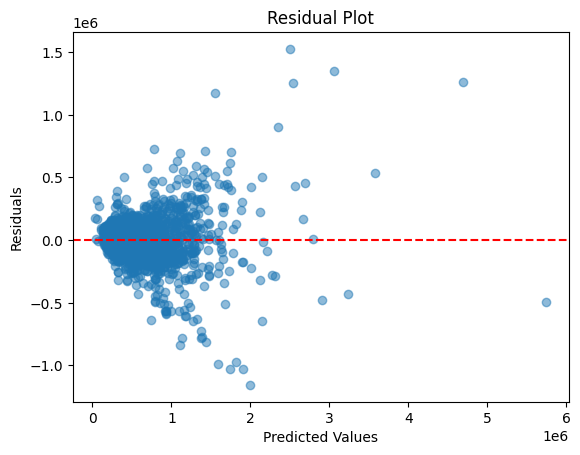

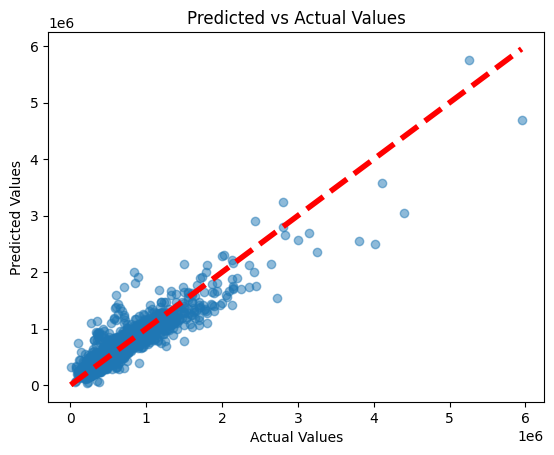

In [31]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.5)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=4)
plt.show()